# Preparacion de datos


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import joblib

# Cargar el dataser limpio
df = pd.read_csv('hotel-cancellation-prediction/data/processed/hotel_bookings_clean_v1.csv')


# 2. Eliminar variables inutiles
columnas_a_eliminar = ['reservation_status', 'reservation_status_date', 'arrival_date_year']
df_model = df.drop(columnas_a_eliminar, axis=1)


# 3. Separar X (Características) e y (Objetivo)
X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

## Feature Selection 
Haremos una seleccion de variables para eliminar las variables que introducen ruido o que producen un mal resultado (que el modelo haga trampa).

### Filtro de Correlacion y Cardinalidad
Ya verificamos (en sandbox.ipynb) que no existean variables que generen multicolinealidad y en la investiacion de cardinalidad encontramos que 'country' tiene una muy alta cardinalidad, entonces la corregimos.

In [2]:
# Reducción de cardinalidad en la variable 'country'
# 1. Distribución original
frecuencias_pais = X['country'].value_counts()

# 2. Extraer los nombres de los 10 países principales
paises_top_10 = frecuencias_pais.head(10).index.tolist()

# 3. Aplicar la regla de negocio: Si no estás en el Top 10, eres 'Other'
X.loc[~X['country'].isin(paises_top_10), 'country'] = 'Other'


## Baseline
Empezaremos con un algoritmo basico (Regresión Logística) que nos ayudara a fjar el "piso" de rendimiento, despues buscaremos superar ese porcentaje de precision con un algoritmo avanzado y optimizado.


--- REPORTE DE CLASIFICACIÓN (BASELINE) ---
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     15002
           1       0.72      0.78      0.75      8840

    accuracy                           0.80     23842
   macro avg       0.79      0.80      0.79     23842
weighted avg       0.81      0.80      0.80     23842



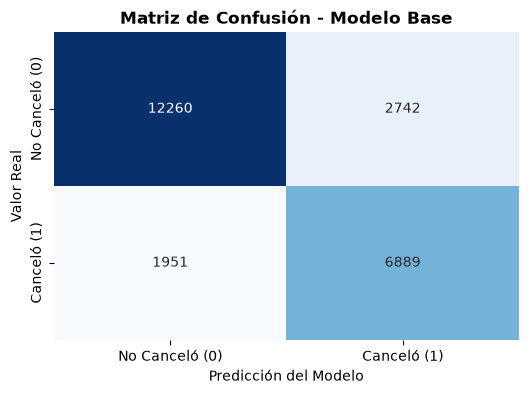

In [6]:
# Definicion de los tipos de columnas
# Separamos qué columnas son números y cuáles son categorías de texto
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'str']).columns.tolist()

# Construccion de los Transformadores
# Escalar números (media 0, varianza 1) para que la Regresión Logística no se confunda con magnitudes
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Codificar texto a binario (One-Hot), ignorando categorías nuevas si aparecen en el futuro
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# Creacion de la Baseline Pipeline
# max_iter=1000 asegura que el algoritmo matemático tenga tiempo de converger
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Particion de los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entrenamiento del modelo de Regresión Logística
baseline_pipeline.fit(X_train, y_train)

# Evaluación del modelo en el conjunto de prueba
y_pred = baseline_pipeline.predict(X_test)

print("\n--- REPORTE DE CLASIFICACIÓN (BASELINE) ---")
print(classification_report(y_test, y_pred))

# Matriz de confusion
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Modelo Base', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.xticks([0.5, 1.5], ['No Canceló (0)', 'Canceló (1)'])
plt.yticks([0.5, 1.5], ['No Canceló (0)', 'Canceló (1)'])
plt.show()

Gracias a la ingenieria de carcteristicas realizada, obtuvimos un 80% de exactitud con un algoritmo basico, ahora buscaremos mejorar ese 80% con un algoritmo complejo y optmizado.

## Entrenamiento e Hiperparameter Tuning
Desarrollamos un modelo de Random Forest mas robusto y utilizaremos GridSearchCV para la optimizacion.

Iniciando la optimización con GridSearchCV (Esto tomará unos minutos)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---
{'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

--- REPORTE DE CLASIFICACIÓN (RANDOM FOREST) ---
              precision    recall  f1-score   support

           0       0.91      0.89      0.90     15002
           1       0.83      0.85      0.84      8840

    accuracy                           0.88     23842
   macro avg       0.87      0.87      0.87     23842
weighted avg       0.88      0.88      0.88     23842



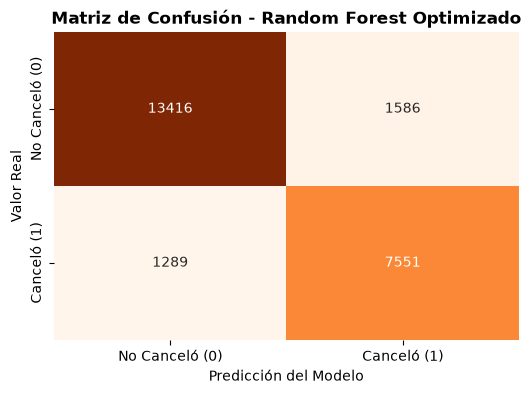

In [8]:
# Ensamblaje del nuevo pipeline con Random Forest para optimización de hiperparámetros
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Definicion del GRID
param_grid = {
    'classifier__n_estimators': [100, 200],       
    'classifier__max_depth': [10, 20, None],     
    'classifier__min_samples_split': [2, 5, 10]   
}

# Configuramos el GRID SEARCH para encontrar los mejores hiperparámetros
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=2 
)

# Entrenamiento del modelo con GridSearchCV
print("Iniciando la optimización con GridSearchCV (Esto tomará unos minutos)...")
grid_search.fit(X_train, y_train)

# Extraccion de resultados
print("\n--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---")
print(grid_search.best_params_)

# Evaluación del mejor modelo optimizado en el conjunto de prueba
best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

print("\n--- REPORTE DE CLASIFICACIÓN (RANDOM FOREST) ---")
print(classification_report(y_test, y_pred_rf))

# Comparacion Grafica
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Matriz de Confusión - Random Forest Optimizado', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.xticks([0.5, 1.5], ['No Canceló (0)', 'Canceló (1)'])
plt.yticks([0.5, 1.5], ['No Canceló (0)', 'Canceló (1)'])
plt.show()

Bien ahora con el entrenamiento del nuevo modelo y con su optimizacion, obtenemos valores superiores a nuestro baseline:
- Recall del 85%: De todas las personas que realmente iban a cancelar, el modelo ahora es capaz de atrapar a casi 9 de cada 10 antes de que suceda.

- Accuracy del 88%: El algoritmo tiene la razón casi el 90% de las veces en el panorama general.

## Exportacion

In [10]:


# grid_search.best_estimator_ contiene el pipeline completo: 
modelo_final = grid_search.best_estimator_

# Guardamos el modelo en la carpeta raíz o en una carpeta 'models/'
ruta_modelo = 'hotel-cancellation-prediction/models/hotel_cancellation_model.pkl' 
joblib.dump(modelo_final, ruta_modelo)


['hotel-cancellation-prediction/models/hotel_cancellation_model.pkl']